# 2_2 Minute Level: RFSV Predictor

本 notebook 使用 `minute_level` 代理方差进行 RFSV 预测，并与 AR/HAR 基准比较。

In [1]:
import sys
import numpy as np
import pandas as pd

sys.path.append('../models')
from HurstEstimator import HurstEstimator
from RFSVPredictor import RFSVPredictor, predict_ar, predict_har, compute_p_ratio

In [2]:
# 读取 minute-level 代理方差
data_file = '../data/variance_proxy_minute_level_20230101_20251231.csv'
df = pd.read_csv(data_file)

if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

rv_col = 'rv_minute' if 'rv_minute' in df.columns else 'rv_uz'
df = df[df[rv_col] > 0].copy()

log_var = np.log(df[rv_col])
var_series = df[rv_col]
display(df.head())
print(f'使用方差列: {rv_col}')
print(f'样本量: {len(df)}')

,rv_minute,n_observations,n_returns,annualized_vol
date,,,,
2023-01-03,0.000011,61,60,5.301845
2023-01-04,0.000008,61,60,4.538374
2023-01-05,0.000011,61,60,5.196513
2023-01-06,0.000006,61,60,3.983375
2023-01-09,0.000010,61,60,4.978114


使用方差列: rv_minute
样本量: 727


In [3]:
# 估计 H 与 nu_sq（与现有主干一致口径）
START_IDX = 500
train_log_sigma = 0.5 * np.log(df[rv_col].iloc[:START_IDX])

hurst = HurstEstimator()
H, h_info = hurst.estimate_hurst_variogram(train_log_sigma, q=2.0)
nu_sq = float(np.exp(h_info['intercept']))

print(f'H = {H:.6f}')
print(f'nu_sq = {nu_sq:.10f}')
print(f'R^2 = {h_info.get("r_squared", np.nan):.6f}')

H = 0.108712
nu_sq = 0.0968891233
R^2 = 0.842328


In [8]:
# RFSV / AR / HAR 在 log-variance 空间比较
deltas = [1, 5, 20]
results = []
mean_log_var = np.mean(log_var.iloc[:START_IDX])

for delta in deltas:
    predictor = RFSVPredictor(H=H, nu_sq=nu_sq, delta=delta, window_ratio=3.0)
    rfsv_pred = predictor.predict_rolling(log_var.values, start_idx=START_IDX)

    ar_pred = predict_ar(log_var.values, delta=delta, p=5, train_window=START_IDX)
    ar_pred_10 = predict_ar(log_var.values, delta=delta, p=10, train_window=START_IDX)
    har_pred = predict_har(log_var.values, delta=delta, train_window=START_IDX)

    actual = log_var.values[START_IDX + delta:]

    rfsv_p = compute_p_ratio(actual, rfsv_pred, mean_log_var)
    ar5_p = compute_p_ratio(actual, ar_pred, mean_log_var)
    ar10_p = compute_p_ratio(actual, ar_pred_10, mean_log_var)
    har_p = compute_p_ratio(actual, har_pred, mean_log_var)

    results.append({
        'delta': delta,
        'RFSV_P': rfsv_p,
        'AR5_P': ar5_p,
        'AR10_P': ar10_p,
        'HAR_P': har_p,
    })

result_df = pd.DataFrame(results)
display(result_df)

,delta,RFSV_P,AR5_P,AR10_P,HAR_P
0,1,0.533643,0.480257,0.487555,0.479050
1,5,0.698455,0.673864,0.678730,0.668509
2,20,1.372779,0.878269,0.883125,0.869335


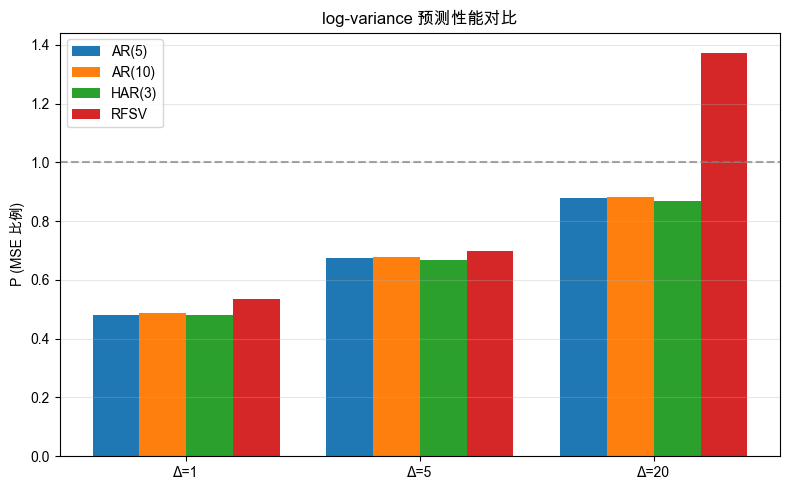

In [14]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['Arial Unicode MS']

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(deltas))
width = 0.2

ax.bar(x - 1.5*width, result_df['AR5_P'], width, label='AR(5)')
ax.bar(x - 0.5*width, result_df['AR10_P'], width, label='AR(10)')
ax.bar(x + 0.5*width, result_df['HAR_P'], width, label='HAR(3)')
ax.bar(x + 1.5*width, result_df['RFSV_P'], width, label='RFSV')
ax.axhline(1, color='gray', linestyle='--', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels([f'Δ={d}' for d in deltas])
ax.set_ylabel('P (MSE 比例)')
ax.set_title('log-variance 预测性能对比')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()